2.5 Unsupervised Learning - Clustering 

K-Means Clustering (with Elbow Method)

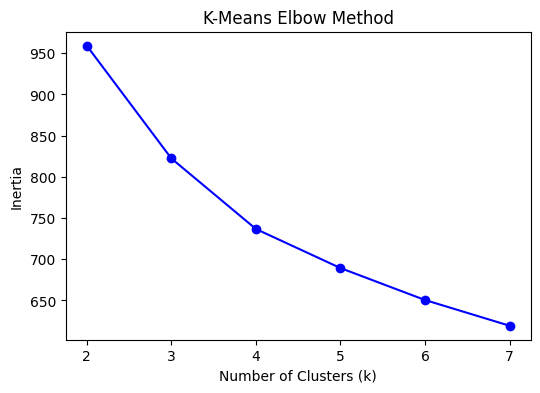

K-Means ARI (vs true labels): 0.256
K-Means Silhouette Score: 0.261


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_cluster = X_reduced  # use reduced feature dataset

# Elbow method
inertias = []
K = range(2, 8)  # test clusters from 2–7
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.show()

# Choose k=2 (since dataset is binary: disease/no disease)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_cluster)

# Compare with actual labels
ari_kmeans = adjusted_rand_score(y_reduced, clusters_kmeans)
sil_kmeans = silhouette_score(X_cluster, clusters_kmeans)
print(f"K-Means ARI (vs true labels): {ari_kmeans:.3f}")
print(f"K-Means Silhouette Score: {sil_kmeans:.3f}")


Hierarchical Clustering (with Dendrogram)

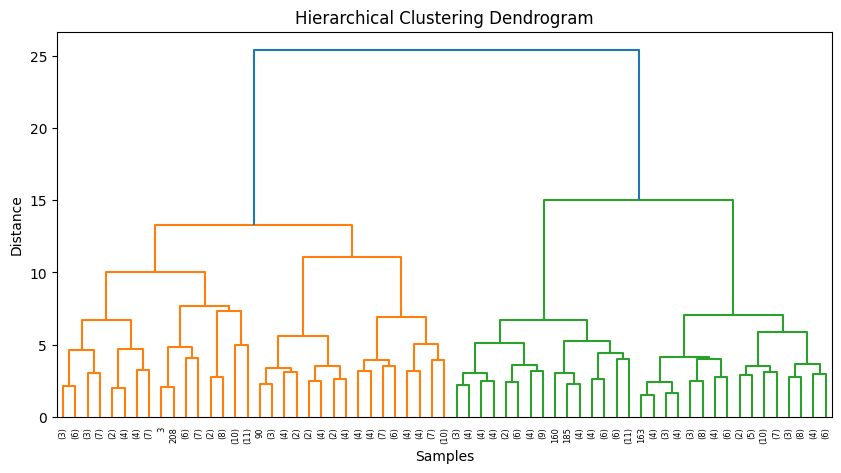

Hierarchical ARI (vs true labels): 0.216
Hierarchical Silhouette Score: 0.212


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Dendrogram
Z = linkage(X_cluster, method="ward")
plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode="level", p=5)  # show last 5 merges
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Fit Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
clusters_hc = hc.fit_predict(X_cluster)

# Compare with actual labels
ari_hc = adjusted_rand_score(y_reduced, clusters_hc)
sil_hc = silhouette_score(X_cluster, clusters_hc)
print(f"Hierarchical ARI (vs true labels): {ari_hc:.3f}")
print(f"Hierarchical Silhouette Score: {sil_hc:.3f}")


comparison code

In [ ]:
# Final K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_reduced)

from sklearn.metrics import adjusted_rand_score, silhouette_score

print("K-Means ARI:", adjusted_rand_score(y_reduced, clusters_kmeans))
print("K-Means Silhouette:", silhouette_score(X_reduced, clusters_kmeans))

# Hierarchical Clustering (Ward, k=2)
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
clusters_hc = hc.fit_predict(X_reduced)

print("Hierarchical ARI:", adjusted_rand_score(y_reduced, clusters_hc))
print("Hierarchical Silhouette:", silhouette_score(X_reduced, clusters_hc))



K-Means ARI: 0.25593626142846254
K-Means Silhouette: 0.2607151187684981
Hierarchical ARI: 0.2164049908758478
Hierarchical Silhouette: 0.21199583490713295
